# Stratified AUC Boxplots

`evaluate_auc.py` output files are used to reproduce `evaluate_delphi.ipynb`-style boxplots for sex-stratified and age-stratified AUC distributions.

In [36]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
font_path = 'figutils/Helvetica.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()

# evaluate_auc.py outputs live in per-run folders under results/ with a
# dataset-specific filename prefix. Switch DATASET below for a single-dataset
# preview, or run the batch cell at the end to regenerate every figure.
RESULTS_BASE = '../results'
DATASET = 'KR'  # one of: KR | JMDC | JMDC_sex | UKB | CKB | KR_full | KR_legacy | UKB_sex | UKB_legacy | CKB_legacy

# KR / UKB / CKB all use the latest age20-100 sex-enabled evaluation run (female/male
# slices + age bins from 20). Earlier 0506 runs are kept as *_legacy / KR_full entries.
_AGE20_SEX_RUN = '0506_age20_100_ckpt_full_no_jmdc_sex_20260604'
_JMDC_RUN = '0506_age20_100_ckpt_jmdc_full_streaming_evalauc_compatible_20260605'
DATASET_CFG = {
    'KR':         {'subdir': _AGE20_SEX_RUN, 'prefix': 'val'},        # kr_val.bin (age 20-95, female/male)
    'UKB':        {'subdir': _AGE20_SEX_RUN, 'prefix': 'extval_ukb'}, # UKB extval (age 20-95, female/male)
    'CKB':        {'subdir': _AGE20_SEX_RUN, 'prefix': 'extval_ckb'}, # CKB extval (age 20-95, female/male)
    'JMDC':       {'subdir': _JMDC_RUN,      'prefix': 'extval_jmdc'}, # JMDC full streaming (age 20-75, 70+ collapsed)
    'JMDC_sex':   {'subdir': '0506/JMDC',    'prefix': 'jmdc'},       # earlier JMDC run w/ female/male slices
    'KR_full':    {'subdir': '0506/KR_rerun_full', 'prefix': 'val'},        # earlier KR rerun (all 20559 patients, age 40+)
    'KR_legacy':  {'subdir': '0506/KR',            'prefix': 'kr'},         # original 0506 KR run (no female/male)
    'UKB_sex':    {'subdir': '0506/UKB_rerun',     'prefix': 'extval_ukb'}, # earlier UKB rerun (age 40+)
    'UKB_legacy': {'subdir': '0506/UKB',           'prefix': 'ukb'},        # original 0506 UKB run (no female/male)
    'CKB_legacy': {'subdir': '0506/CKB',           'prefix': 'extval_ckb'}, # original 0506 CKB run (age 40+)
}
_cfg = DATASET_CFG[DATASET]
RESULTS_DIR = os.path.join(RESULTS_BASE, _cfg['subdir'])
PREFIX = _cfg['prefix']

SEX_CSV = os.path.join(RESULTS_DIR, f'{PREFIX}_df_both_by_sex.csv')
AGE_CSV = os.path.join(RESULTS_DIR, f'{PREFIX}_df_auc_unpooled.csv')

normal_male = '#2166ac'
normal_female = '#b2182b'

# Age groups are colored on a single light->dark gradient between these two
# endpoints, sampled at evenly-spaced steps (one per age bin) so the shade
# increases monotonically with age instead of cycling through a fixed list.
from matplotlib.colors import LinearSegmentedColormap
AGE_CMAP_ENDPOINTS = ['#DCEAF7', '#1E467D']
age_cmap = LinearSegmentedColormap.from_list('age_blues', AGE_CMAP_ENDPOINTS)

def age_colors(n):
    """Return `n` colors evenly spaced across the age gradient (endpoints inclusive)."""
    if n <= 1:
        return [age_cmap(1.0)]
    return [age_cmap(i / (n - 1)) for i in range(n)]

In [37]:
def _pick_auc_col(df: pd.DataFrame) -> str:
    if 'auc_delong' in df.columns and df['auc_delong'].notna().any():
        return 'auc_delong'
    if 'auc' in df.columns:
        return 'auc'
    raise ValueError('Could not find an AUC column.')


def _build_age_labels(df: pd.DataFrame) -> pd.Series:
    if 'age_bin_years' in df.columns:
        return df['age_bin_years'].astype(str)
    ages = np.sort(df['age'].dropna().unique())
    if len(ages) >= 2:
        step = ages[1] - ages[0]
        return df['age'].map(lambda a: f'[{int(a)}, {int(a + step)})')
    return df['age'].map(lambda a: f'[{int(a)}, ?)')


# Ages >= this threshold are merged into one "{thr}+" bin. The oldest age
# groups (e.g. 95-99) often have only a handful of evaluable tokens with tiny
# case/control counts, which makes AUC trivially 1.0 and produces a degenerate
# (zero-width) boxplot. Merging them with the preceding bin keeps the tail bin
# statistically meaningful. Datasets whose max age is below the threshold are
# unaffected.
AGE_PLUS_THRESHOLD = 90
AGE_PLUS_THRESHOLD_BY_DATASET = {'JMDC': 70}  # matches 70plus_collapsed_from_5yr post-hoc summary

def _age_plus_threshold(dataset):
    return AGE_PLUS_THRESHOLD_BY_DATASET.get(dataset, AGE_PLUS_THRESHOLD)

def _build_age_groups(df, plus_threshold=AGE_PLUS_THRESHOLD, step=5):
    """Return (labels, list-of-AUC-arrays) with the oldest ages merged.

    Ages below `plus_threshold` keep individual 5-year bins ('a-a+4'); all ages
    >= plus_threshold collapse into a single '{plus_threshold}+' bin.
    """
    ages = sorted(df['age'].dropna().unique())
    labels, data = [], []
    for a in (x for x in ages if x < plus_threshold):
        labels.append(f'{int(a)}-{int(a + step - 1)}')
        data.append(df.loc[df['age'] == a, 'auc_value'].values)
    tail = [x for x in ages if x >= plus_threshold]
    if tail:
        labels.append(f'{int(plus_threshold)}+')
        data.append(df.loc[df['age'].isin(tail), 'auc_value'].values)
    return labels, data


def _display_age_labels(labels, dataset=None):
    """Display-only relabelling for x-axis ticks (does not change binning)."""
    labels = list(labels)
    if dataset == 'UKB' and labels and labels[-1] == '80-84':
        labels[-1] = '80+'
    return labels


sex_df = pd.read_csv(SEX_CSV)
sex_auc_col = _pick_auc_col(sex_df)
sex_status_mask = sex_df['status'] == 'ok' if 'status' in sex_df.columns else True
sex_df = sex_df[(sex_df['sex'].isin(['female', 'male'])) & sex_status_mask].copy()
sex_df['auc_value'] = pd.to_numeric(sex_df[sex_auc_col], errors='coerce')
sex_df = sex_df.dropna(subset=['auc_value'])

age_df = pd.read_csv(AGE_CSV)
age_auc_col = _pick_auc_col(age_df)
if 'sex' in age_df.columns:
    age_df = age_df[age_df['sex'] == 'all'].copy()
age_status_mask = age_df['status'] == 'ok' if 'status' in age_df.columns else True
age_df = age_df[age_status_mask].copy()
age_df['auc_value'] = pd.to_numeric(age_df[age_auc_col], errors='coerce')
age_df = age_df.dropna(subset=['auc_value'])
age_df['age_label'] = _build_age_labels(age_df)

print(f'[{DATASET}] sex rows:', len(sex_df), '| tokens:', sex_df['token'].nunique() if len(sex_df) else 0)
print(f'[{DATASET}] age rows:', len(age_df), '| age bins:', age_df['age_label'].nunique())
if len(sex_df) == 0:
    print(f'  (no female/male slices present for {DATASET} — sex boxplot will be empty)')

[KR] sex rows: 1650 | tokens: 943
[KR] age rows: 8568 | age bins: 16


/tmp/ipykernel_3817614/3971398694.py:69: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  age_df = age_df[age_status_mask].copy()


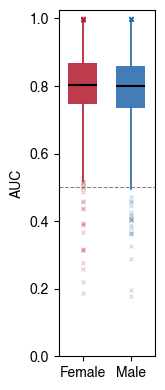

In [38]:
# Sex-stratified AUC boxplot
female_data = sex_df.loc[sex_df['sex'] == 'female', 'auc_value'].values
male_data = sex_df.loc[sex_df['sex'] == 'male', 'auc_value'].values

fig, ax = plt.subplots(figsize=(1.75, 4))

sex_data = [female_data, male_data]
sex_colors = [normal_female, normal_male]
sex_labels = ['Female', 'Male']
positions = [1, 2]

for i in range(2):
    if len(sex_data[i]) == 0:
        continue
    ax.boxplot(
        sex_data[i], positions=[positions[i]], patch_artist=True,
        widths=0.6, whis=[2.5, 97.5], showfliers=True,
        showcaps=False,
        boxprops={'linewidth': 0, 'facecolor': sex_colors[i], 'edgecolor': sex_colors[i], 'alpha':0.85},
        medianprops={'color': 'black', 'linewidth': 1.5},
        whiskerprops={'color': sex_colors[i], 'linewidth': 1.2},
        flierprops={'marker': 'x', 'markerfacecolor': 'none', 'markeredgecolor': sex_colors[i], 'markersize': 3, 'alpha': 0.2},
    )

ax.set_xticks(positions)
ax.set_xticklabels(sex_labels)
ax.set_ylim(0, 1.025)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.75)
ax.set_axisbelow(True)
ax.set_ylabel('AUC')
plt.tight_layout()
plt.grid(axis='x', visible=False)
plt.savefig(f'out/auc_sex_stratified_{DATASET}.pdf', bbox_inches='tight')
plt.show()

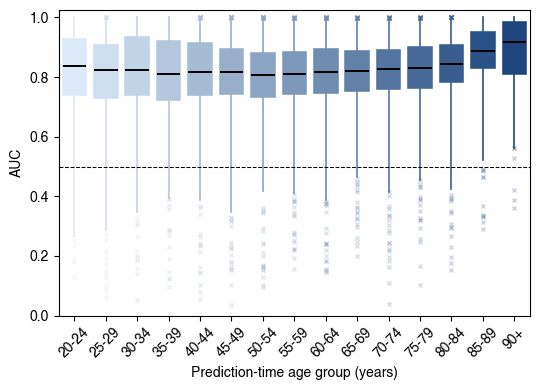

In [39]:
# Age-stratified AUC boxplot (all sexes pooled); oldest ages merged into "{thr}+"
age_labels, age_data = _build_age_groups(age_df, plus_threshold=_age_plus_threshold(DATASET))
age_labels = _display_age_labels(age_labels, DATASET)
positions = np.arange(1, len(age_labels) + 1)

fig_width = max(5.5, 0.3 * len(age_labels))
fig, ax = plt.subplots(figsize=(fig_width, 4))

age_box_colors = age_colors(len(age_data))
for i, values in enumerate(age_data):
    color = age_box_colors[i]
    if len(values) == 0:
        continue
    ax.boxplot(
        values, positions=[positions[i]], patch_artist=True,
        widths=0.75, whis=[2.5, 97.5], showfliers=True,
        showcaps=False,
        boxprops={'linewidth': 1.15, 'facecolor': color, 'edgecolor': color},
        medianprops={'color': 'black', 'linewidth': 1.4},
        whiskerprops={'color': color, 'linewidth': 1.2},
        flierprops={'marker': 'x', 'markerfacecolor': 'none', 'markeredgecolor': color, 'markersize': 2.5, 'alpha': 0.25},
    )

ax.set_xticks(positions)
ax.set_xticklabels(age_labels, ha='center', fontsize=10, rotation=45)
ax.set_ylim(0, 1.025)
ax.axhline(0.5, color='black', linestyle='--', linewidth=0.75)
ax.set_axisbelow(True)
ax.set_ylabel('AUC')
ax.set_xlabel('Prediction-time age group (years)', fontsize=10)
# ax.margins(x=100)
plt.tight_layout()
plt.grid(axis='x', visible=False)
plt.savefig(f'out/auc_age_stratified_{DATASET}.pdf', bbox_inches='tight')
plt.show()

## Batch: KR / JMDC / UKB all stratifications

The cells above are convenient for a single-dataset preview. The next cell regenerates **all six PDFs** in one shot: sex-stratified and age-stratified boxplots for KR, JMDC, and UKB (using the rerun folders that contain female/male slices).

[KR] sex<-KR rows=1650 (tokens=943) | age<-KR rows=8568 bins=16


/tmp/ipykernel_3817614/3746192870.py:35: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  adf = adf[a_mask].copy()
/tmp/ipykernel_3817614/3746192870.py:35: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  adf = adf[a_mask].copy()


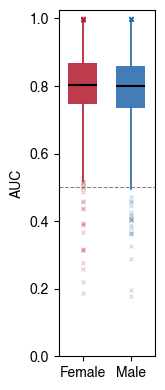

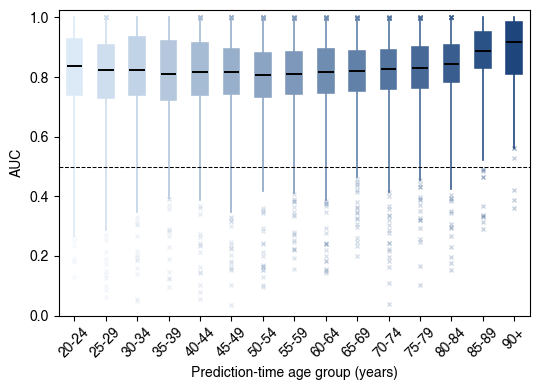

[JMDC] sex<-JMDC_sex rows=1668 (tokens=937) | age<-JMDC rows=11357 bins=12


/tmp/ipykernel_3817614/3746192870.py:35: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  adf = adf[a_mask].copy()


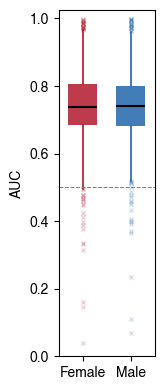

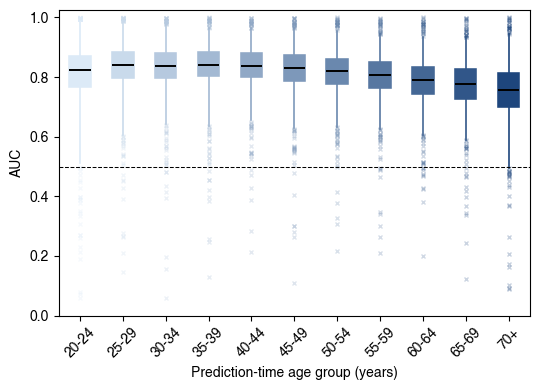

[UKB] sex<-UKB rows=1993 (tokens=1100) | age<-UKB rows=10131 bins=13


/tmp/ipykernel_3817614/3746192870.py:35: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  adf = adf[a_mask].copy()
/tmp/ipykernel_3817614/3746192870.py:35: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  adf = adf[a_mask].copy()


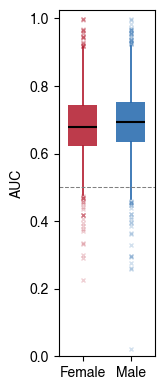

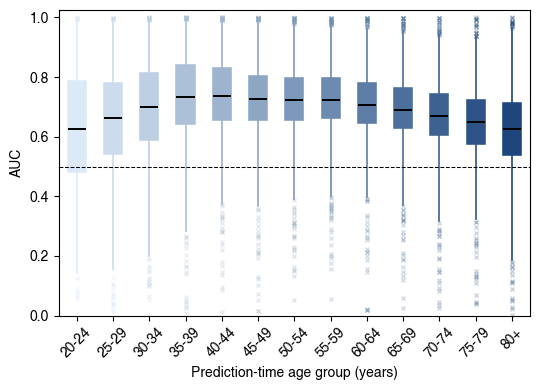

[CKB] sex<-CKB rows=45 (tokens=24) | age<-CKB rows=255 bins=14


/tmp/ipykernel_3817614/3746192870.py:35: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  adf = adf[a_mask].copy()
/tmp/ipykernel_3817614/3746192870.py:35: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  adf = adf[a_mask].copy()


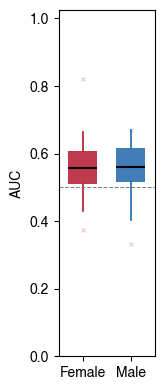

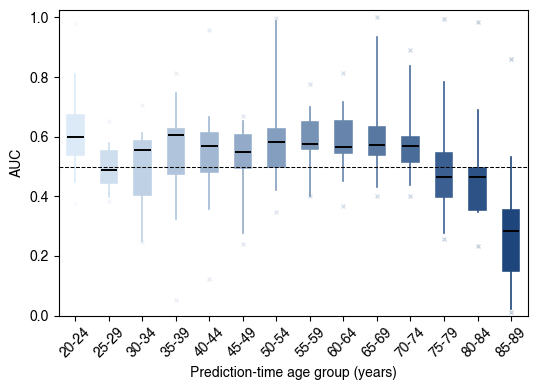

,sex_source,age_source,sex_rows,sex_tokens,age_rows,age_bins
dataset,,,,,,
KR,KR,KR,1650,943,8568,16
JMDC,JMDC_sex,JMDC,1668,937,11357,12
UKB,UKB,UKB,1993,1100,10131,13
CKB,CKB,CKB,45,24,255,14


In [40]:
# Batch generator: KR / JMDC / UKB / CKB × {sex-stratified, age-stratified}
# Saves PDFs to figure/out/. Re-applies sex-run paths here so UKB/CKB are not
# stuck on a stale kernel config from before cell 1 was re-run.
_AGE20_SEX_RUN = '0506_age20_100_ckpt_full_no_jmdc_sex_20260604'
for _key, _prefix in [('KR', 'val'), ('UKB', 'extval_ukb'), ('CKB', 'extval_ckb')]:
    DATASET_CFG[_key] = {'subdir': _AGE20_SEX_RUN, 'prefix': _prefix}

_JMDC_RUN = '0506_age20_100_ckpt_jmdc_full_streaming_evalauc_compatible_20260605'
DATASET_CFG['JMDC'] = {'subdir': _JMDC_RUN, 'prefix': 'extval_jmdc'}
DATASET_CFG.setdefault('JMDC_sex', {'subdir': '0506/JMDC', 'prefix': 'jmdc'})

def _load_dataset(name):
    """Load and filter sex_df / age_df for one dataset key from DATASET_CFG."""
    cfg = DATASET_CFG[name]
    rdir = os.path.join(RESULTS_BASE, cfg['subdir'])
    pfx = cfg['prefix']
    sex_csv = os.path.join(rdir, f'{pfx}_df_both_by_sex.csv')
    age_csv = os.path.join(rdir, f'{pfx}_df_auc_unpooled.csv')

    if os.path.exists(sex_csv):
        sdf = pd.read_csv(sex_csv)
        s_auc_col = _pick_auc_col(sdf)
        s_mask = sdf['status'] == 'ok' if 'status' in sdf.columns else True
        sdf = sdf[(sdf['sex'].isin(['female', 'male'])) & s_mask].copy()
        sdf['auc_value'] = pd.to_numeric(sdf[s_auc_col], errors='coerce')
        sdf = sdf.dropna(subset=['auc_value'])
    else:
        sdf = pd.DataFrame(columns=['sex', 'auc_value', 'token'])

    adf = pd.read_csv(age_csv)
    a_auc_col = _pick_auc_col(adf)
    if 'sex' in adf.columns:
        adf = adf[adf['sex'] == 'all'].copy()
    a_mask = adf['status'] == 'ok' if 'status' in adf.columns else True
    adf = adf[a_mask].copy()
    adf['auc_value'] = pd.to_numeric(adf[a_auc_col], errors='coerce')
    adf = adf.dropna(subset=['auc_value'])
    adf['age_label'] = _build_age_labels(adf)
    return sdf, adf


def _plot_sex(sdf, name, save_path):
    female_data = sdf.loc[sdf['sex'] == 'female', 'auc_value'].values
    male_data = sdf.loc[sdf['sex'] == 'male', 'auc_value'].values
    fig, ax = plt.subplots(figsize=(1.75, 4))
    data, colors, labels, positions = (
        [female_data, male_data], [normal_female, normal_male], ['Female', 'Male'], [1, 2]
    )
    for i in range(2):
        if len(data[i]) == 0:
            continue
        ax.boxplot(
            data[i], positions=[positions[i]], patch_artist=True,
            widths=0.6, whis=[2.5, 97.5], showfliers=True, showcaps=False,
            boxprops={'linewidth': 0, 'facecolor': colors[i], 'edgecolor': colors[i], 'alpha': 0.85},
            medianprops={'color': 'black', 'linewidth': 1.5},
            whiskerprops={'color': colors[i], 'linewidth': 1.2},
            flierprops={'marker': 'x', 'markerfacecolor': 'none', 'markeredgecolor': colors[i],
                        'markersize': 3, 'alpha': 0.2},
        )
    ax.set_xticks(positions)
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 1.025)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.75)
    ax.set_axisbelow(True)
    ax.set_ylabel('AUC')
    # ax.set_title(name, y=1.03, fontsize=10)
    plt.tight_layout()
    plt.grid(axis='x', visible=False)
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()


def _plot_age(adf, name, save_path):
    age_labels_, age_data = _build_age_groups(adf, plus_threshold=_age_plus_threshold(name))
    age_labels_ = _display_age_labels(age_labels_, name)
    positions = np.arange(1, len(age_labels_) + 1)
    fig_width = max(5.5, 0.3 * len(age_labels_))
    fig, ax = plt.subplots(figsize=(fig_width, 4))
    age_box_colors = age_colors(len(age_data))
    for i, values in enumerate(age_data):
        if len(values) == 0:
            continue
        color = age_box_colors[i]
        ax.boxplot(
            values, positions=[positions[i]], patch_artist=True,
            widths=0.5, whis=[2.5, 97.5], showfliers=True, showcaps=False,
            boxprops={'linewidth': 1.15, 'facecolor': color, 'edgecolor': color},
            medianprops={'color': 'black', 'linewidth': 1.4},
            whiskerprops={'color': color, 'linewidth': 1.2},
            flierprops={'marker': 'x', 'markerfacecolor': 'none', 'markeredgecolor': color,
                        'markersize': 2.5, 'alpha': 0.25},
        )
    ax.set_xticks(positions)
    ax.set_xticklabels(age_labels_, ha='center', fontsize=10, rotation=45)
    ax.set_ylim(0, 1.025)
    ax.axhline(0.5, color='black', linestyle='--', linewidth=0.75)
    ax.set_axisbelow(True)
    ax.set_ylabel('AUC')
    ax.set_xlabel('Prediction-time age group (years)', fontsize=10)
    # ax.set_title(name, y=1.03, fontsize=10)
    plt.tight_layout()
    plt.grid(axis='x', visible=False)
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()


# All four datasets use the same run for age + sex (KR/UKB/CKB -> age20 sex run).
BATCH_CFG = {
    'KR':   {'age': 'KR',   'sex': 'KR'},
    'JMDC': {'age': 'JMDC', 'sex': 'JMDC_sex'},  # new age run has no sex slices
    'UKB':  {'age': 'UKB',  'sex': 'UKB'},
    'CKB':  {'age': 'CKB',  'sex': 'CKB'},
}
batch_summary = []
for name, keys in BATCH_CFG.items():
    sdf_, _ = _load_dataset(keys['sex'])
    _, adf_ = _load_dataset(keys['age'])
    if name in ('UKB', 'CKB') and len(sdf_) == 0:
        raise RuntimeError(
            f'[{name}] sex_rows=0 — expected female/male in '
            f'{DATASET_CFG[name]["subdir"]}/{DATASET_CFG[name]["prefix"]}_df_both_by_sex.csv. '
            'Re-run cell 1 or the batch preamble above.'
        )
    print(f'[{name}] sex<-{keys["sex"]} rows={len(sdf_)} (tokens={sdf_["token"].nunique() if len(sdf_) else 0}) | '
          f'age<-{keys["age"]} rows={len(adf_)} bins={adf_["age_label"].nunique()}')
    _plot_sex(sdf_, name, f'out/auc_sex_stratified_{name}.pdf')
    _plot_age(adf_, name, f'out/auc_age_stratified_{name}.pdf')
    batch_summary.append({
        'dataset': name,
        'sex_source': keys['sex'],
        'age_source': keys['age'],
        'sex_rows': len(sdf_),
        'sex_tokens': int(sdf_['token'].nunique()) if len(sdf_) else 0,
        'age_rows': len(adf_),
        'age_bins': int(adf_['age_label'].nunique()),
    })

pd.DataFrame(batch_summary).set_index('dataset')